In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns

Actúa como un **Data Analyst especializado en EDA**.

Recibirás un dataset limpio. Realiza un análisis exploratorio breve pero completo, generando visualizaciones clave.

**1. VISIÓN GENERAL**
- Dimensiones del dataset (filas, columnas).
- Estadísticas descriptivas básicas (media, mediana, min, max) para columnas numéricas.
- Distribución de tipos de datos.

**2. ANÁLISIS UNIVARIADO (gráficos)**
- **Distribución de ventas**: Histograma de Total por order.
- **Top categorías**: Gráfico de barras con cantidad de órdenes por Category.
- **Estado de órdenes**: Gráfico de torta o barras para Status (Shipped, Delivered, Cancelled, etc.).
- **Métodos de pago**: Barras con frecuencia por Payment_Method.

**3. ANÁLISIS BIVARIADO (gráficos)**
- **Ventas por mes**: Línea de tiempo con Total de ventas mensuales.
- **Total por categoría**: Boxplot o barras agrupadas mostrando distribución de Total por Category.
- **Cantidad vs Total**: Scatter plot de Quantity vs Total (identificar outliers).
- **Método de pago por categoría**: Heatmap o barras apiladas.

**4. INSIGHTS CLAVE**
- 3-5 hallazgos principales (ej: categoría más vendida, mes con más ingresos, tasa de cancelación por categoría).
- Outliers detectados y su posible explicación.

**5. RECOMENDACIONES**
- Sugerencias para negocio basadas en patrones detectados.

**FORMATO DE SALIDA:**
- Texto conciso con hallazgos.
- Visualizaciones descritas en texto (o genera el código si el entorno lo permite).
- Prioriza claridad sobre extensión.



Dataset cargado: 82 filas x 13 columnas
Nulos por columna:
Category    7

Figura guardada en: eda_ecommerce.png


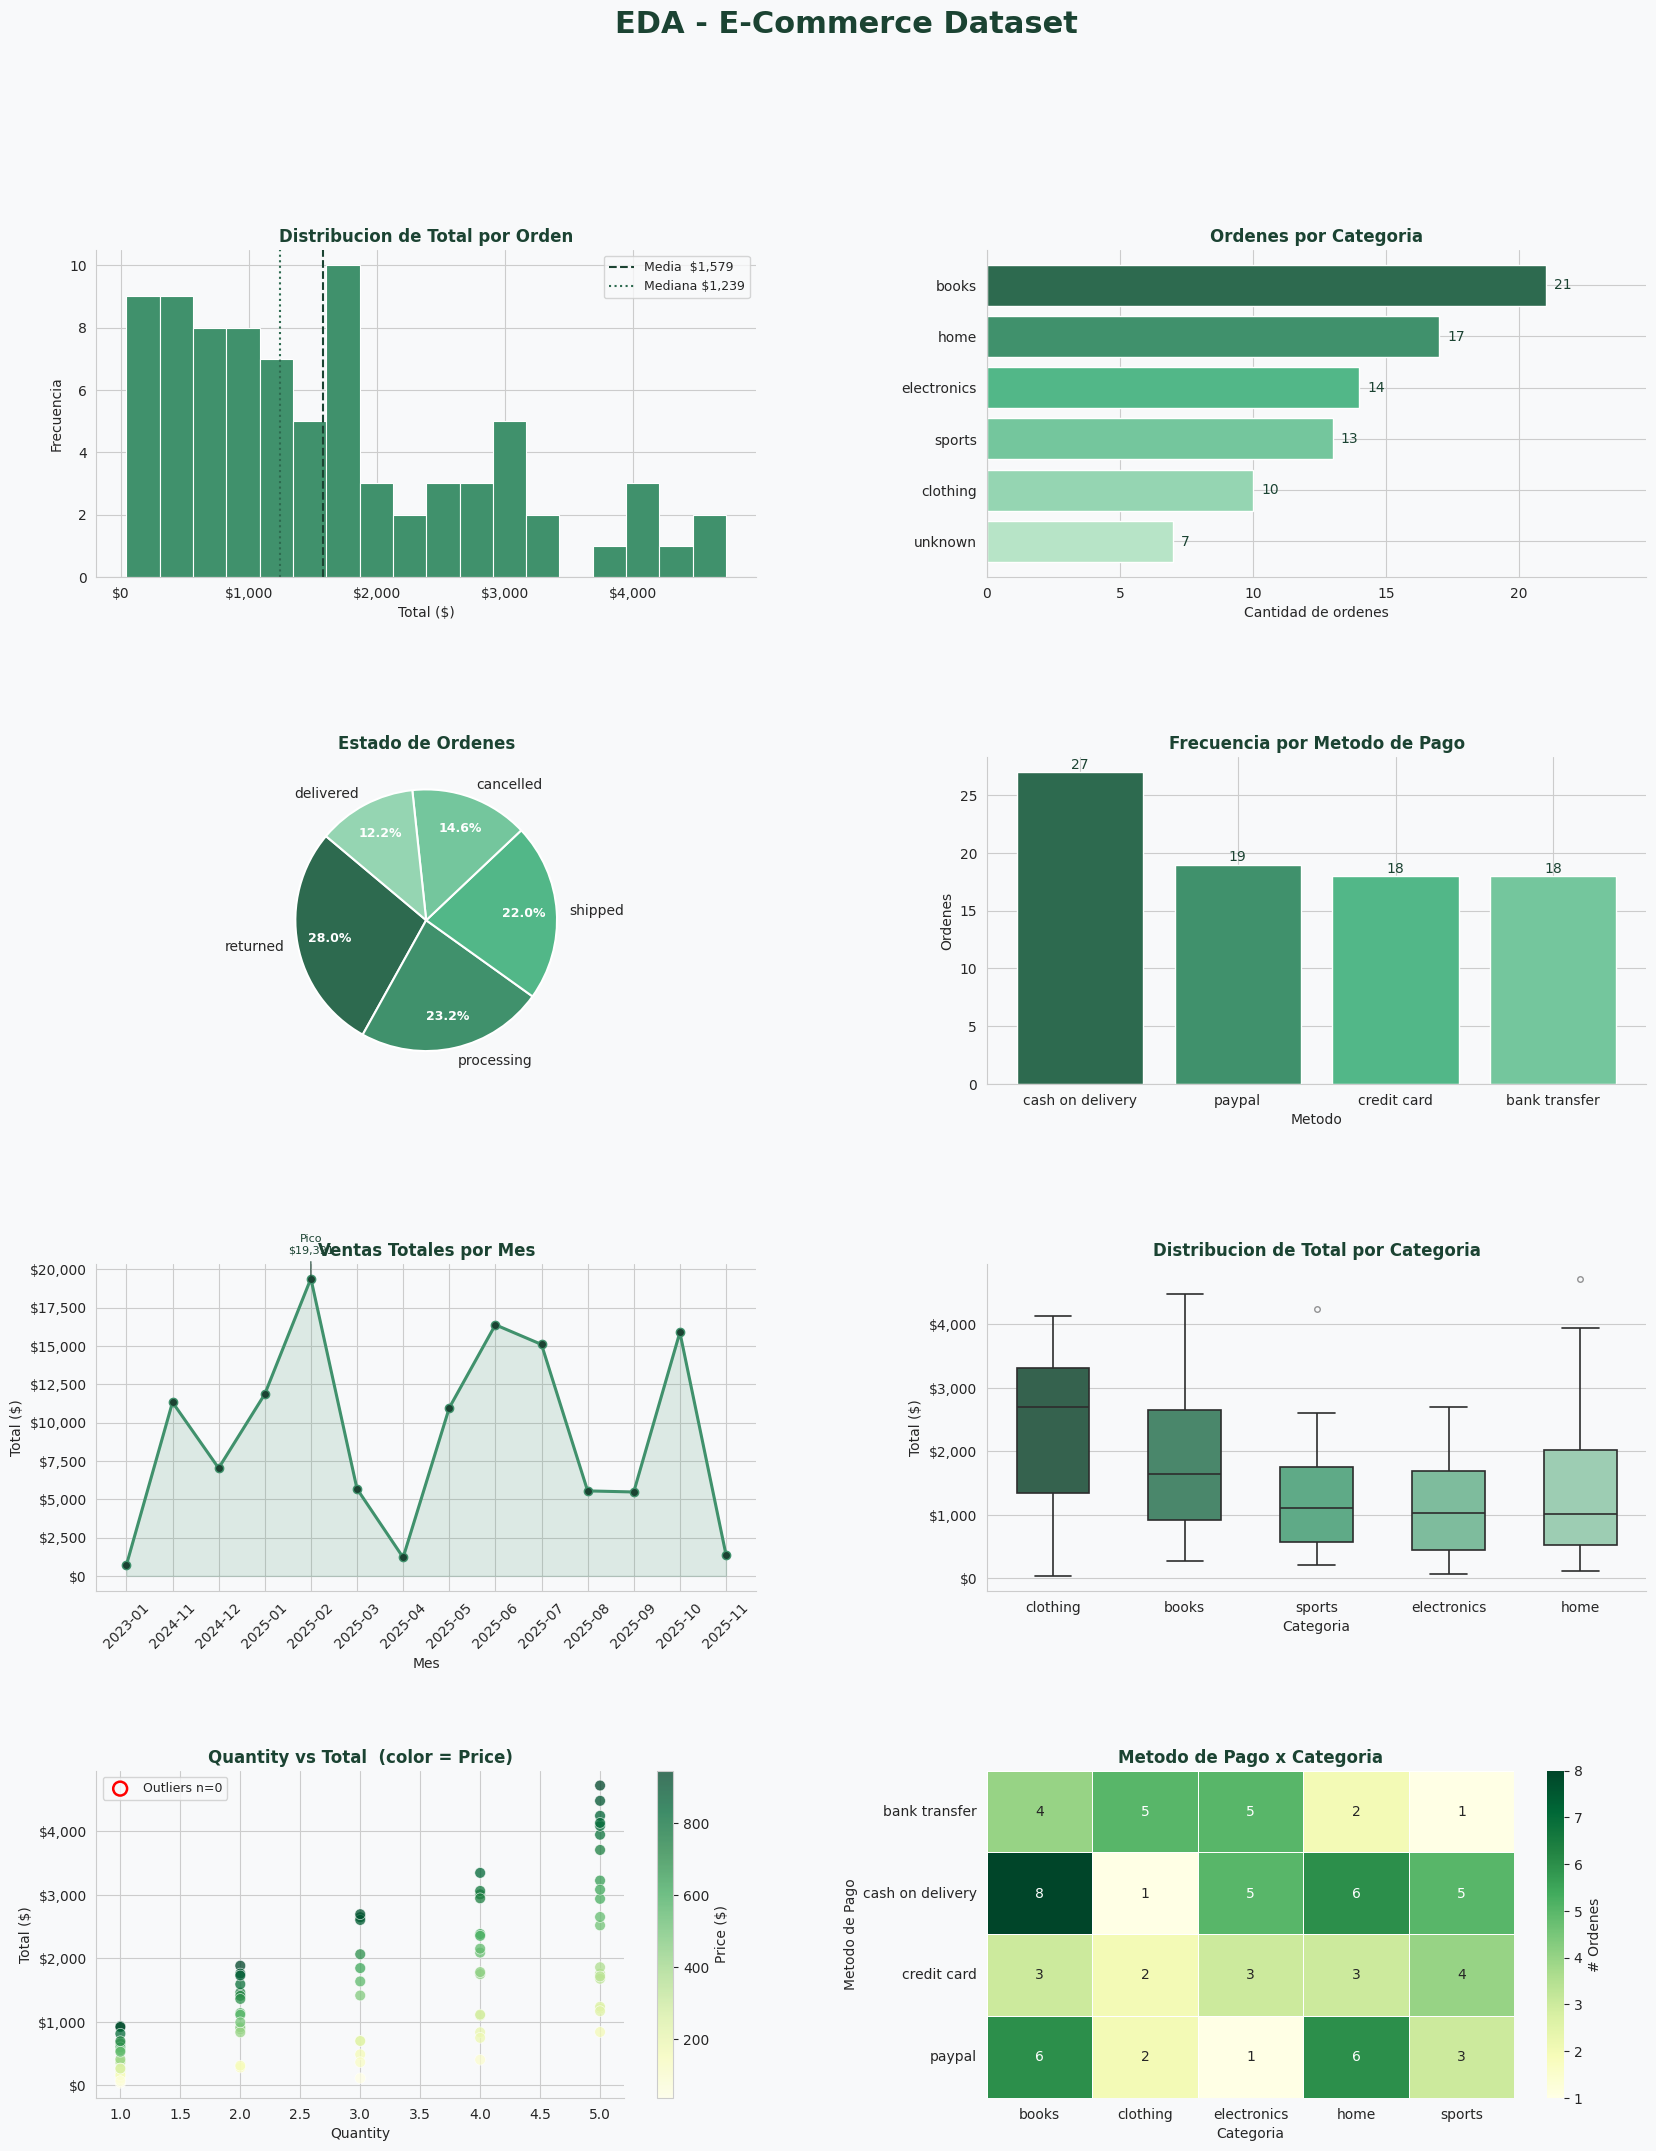


========== ESTADISTICAS DESCRIPTIVAS ==========
       Quantity   Price    Total
count     81.00   81.00    81.00
mean       3.02  512.44  1578.83
std        1.52  263.05  1193.73
min        1.00   38.00    40.95
25%        2.00  266.70   660.98
50%        3.00  531.06  1239.10
75%        4.00  736.71  2355.92
max        5.00  944.54  4722.70

========== INSIGHTS CLAVE ==========
  * Categoria mas vendida : books (21 ordenes)
  * Mes con mas ingresos  : 2025-02  ($19,391.34)
  * Tasa de cancelacion   : 14.6%
  * Tasa de devoluciones  : 28.0%  -- muy alta
  * Metodo de pago top    : cash on delivery (27 ordenes)
  * Precios negativos     : 1 registro(s) erroneo(s)

========== RECOMENDACIONES ==========
  1. Investigar causa de devoluciones (28%): revisar calidad de producto y descripciones.
  2. Incentivar pagos digitales sobre Cash on Delivery para reducir riesgo logistico.
  3. Potenciar Electronics y Home: ticket promedio mas alto, margen para campanas.
  4. Auditar y corregir regis

In [5]:

# ─────────────────────────────────────────────
# 0. CARGA Y PREPARACIÓN
# ─────────────────────────────────────────────
# ✅ Ruta relativa: coloca el CSV en la misma carpeta que este script
CSV_PATH = "clean_ecommerce_data.csv"
OUT_PATH  = "eda_ecommerce.png"

df = pd.read_csv(CSV_PATH)

# Parsear fecha y extraer mes
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
df["YearMonth"]  = df["Order_Date"].dt.to_period("M")

# Eliminar negativos espurios (outliers de precio/total)
df_clean = df[(df["Price"] >= 0) & (df["Total"] >= 0)].copy()

# Rellenar Category NaN con "unknown" para análisis categórico
df["Category_filled"] = df["Category"].fillna("unknown")

print(f"Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Nulos por columna:\n{df.isnull().sum()[df.isnull().sum() > 0].to_string()}\n")

# ─────────────────────────────────────────────
# PALETA Y ESTILOS
# ─────────────────────────────────────────────
PALETTE = "#2D6A4F #40916C #52B788 #74C69D #95D5B2 #B7E4C7".split()
ACCENT  = "#1B4332"
BG      = "#F8F9FA"
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   BG,
    "font.family":      "DejaVu Sans",
    "axes.spines.top":  False,
    "axes.spines.right":False,
})

# ─────────────────────────────────────────────
# FIGURA PRINCIPAL  (4 x 2 = 8 paneles)
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(20, 24), facecolor=BG)
fig.suptitle("EDA - E-Commerce Dataset", fontsize=22, fontweight="bold",
             color=ACCENT, y=0.98)

gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.55, wspace=0.35)

# ── 2.1 UNIVARIADO: Histograma de Total ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
valid_totals = df_clean["Total"]
ax1.hist(valid_totals, bins=18, color=PALETTE[1], edgecolor="white", linewidth=0.8)
ax1.axvline(valid_totals.mean(),   color=ACCENT,     linestyle="--", linewidth=1.5,
            label=f"Media  ${valid_totals.mean():,.0f}")
ax1.axvline(valid_totals.median(), color=PALETTE[0], linestyle=":",  linewidth=1.5,
            label=f"Mediana ${valid_totals.median():,.0f}")
ax1.set_title("Distribucion de Total por Orden", fontweight="bold", color=ACCENT)
ax1.set_xlabel("Total ($)")
ax1.set_ylabel("Frecuencia")
ax1.legend(fontsize=9)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# ── 2.2 UNIVARIADO: Top Categorias ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
cat_counts = df["Category_filled"].value_counts()
bars = ax2.barh(cat_counts.index[::-1], cat_counts.values[::-1],
                color=PALETTE[:len(cat_counts)][::-1], edgecolor="white")
for bar, val in zip(bars, cat_counts.values[::-1]):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
             str(val), va="center", fontsize=10, color=ACCENT)
ax2.set_title("Ordenes por Categoria", fontweight="bold", color=ACCENT)
ax2.set_xlabel("Cantidad de ordenes")
ax2.set_xlim(0, cat_counts.max() * 1.18)

# ── 2.3 UNIVARIADO: Estado de ordenes (pie) ─────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
status_counts = df["Status"].value_counts()
wedges, texts, autotexts = ax3.pie(
    status_counts.values,
    labels=status_counts.index,
    colors=PALETTE[:len(status_counts)],
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor="white", linewidth=1.5),
)
for t in autotexts:
    t.set_fontsize(9)
    t.set_color("white")
    t.set_fontweight("bold")
ax3.set_title("Estado de Ordenes", fontweight="bold", color=ACCENT)

# ── 2.4 UNIVARIADO: Metodos de pago ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
pay_counts = df["Payment_Method"].value_counts()
ax4.bar(pay_counts.index, pay_counts.values,
        color=PALETTE[:len(pay_counts)], edgecolor="white")
ax4.set_title("Frecuencia por Metodo de Pago", fontweight="bold", color=ACCENT)
ax4.set_xlabel("Metodo")
ax4.set_ylabel("Ordenes")
for i, v in enumerate(pay_counts.values):
    ax4.text(i, v + 0.3, str(v), ha="center", fontsize=10, color=ACCENT)

# ── 3.1 BIVARIADO: Ventas mensuales ─────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
monthly = (
    df_clean.dropna(subset=["YearMonth"])
    .groupby("YearMonth")["Total"].sum()
    .sort_index()
)
x_labels = [str(p) for p in monthly.index]
ax5.plot(x_labels, monthly.values, marker="o", color=PALETTE[1],
         linewidth=2.2, markersize=6, markerfacecolor=ACCENT)
ax5.fill_between(x_labels, monthly.values, alpha=0.15, color=PALETTE[1])
ax5.set_title("Ventas Totales por Mes", fontweight="bold", color=ACCENT)
ax5.set_xlabel("Mes")
ax5.set_ylabel("Total ($)")
ax5.tick_params(axis="x", rotation=45)
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
# Anotar el mes pico
peak_idx = monthly.values.argmax()
ax5.annotate(f"Pico\n${monthly.values[peak_idx]:,.0f}",
             xy=(x_labels[peak_idx], monthly.values[peak_idx]),
             xytext=(0, 18), textcoords="offset points",
             ha="center", fontsize=8, color=ACCENT,
             arrowprops=dict(arrowstyle="-", color=ACCENT, lw=0.8))

# ── 3.2 BIVARIADO: Boxplot Total por Categoria ──────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
df_clean_cat = df_clean.dropna(subset=["Category"])
cat_order = (df_clean_cat.groupby("Category")["Total"]
             .median().sort_values(ascending=False).index)
sns.boxplot(data=df_clean_cat, x="Category", y="Total", order=cat_order,
            palette=PALETTE[:len(cat_order)], width=0.55, linewidth=1.2,
            flierprops=dict(marker="o", markersize=4, alpha=0.5), ax=ax6)
ax6.set_title("Distribucion de Total por Categoria", fontweight="bold", color=ACCENT)
ax6.set_xlabel("Categoria")
ax6.set_ylabel("Total ($)")
ax6.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# ── 3.3 BIVARIADO: Scatter Quantity vs Total ─────────────────────────────────
ax7 = fig.add_subplot(gs[3, 0])
sc = ax7.scatter(
    df_clean["Quantity"], df_clean["Total"],
    c=df_clean["Price"], cmap="YlGn", alpha=0.75,
    edgecolors="white", linewidths=0.5, s=60
)
plt.colorbar(sc, ax=ax7, label="Price ($)")
# Resaltar outliers (Total > Q3 + 1.5xIQR)
q1, q3 = df_clean["Total"].quantile([0.25, 0.75])
iqr = q3 - q1
outliers = df_clean[df_clean["Total"] > q3 + 1.5 * iqr]
ax7.scatter(outliers["Quantity"], outliers["Total"],
            edgecolors="red", facecolors="none", s=100, linewidths=1.8,
            label=f"Outliers n={len(outliers)}")
ax7.set_title("Quantity vs Total  (color = Price)", fontweight="bold", color=ACCENT)
ax7.set_xlabel("Quantity")
ax7.set_ylabel("Total ($)")
ax7.legend(fontsize=9)
ax7.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# ── 3.4 BIVARIADO: Heatmap Metodo de Pago x Categoria ───────────────────────
ax8 = fig.add_subplot(gs[3, 1])
heat_df = (df.dropna(subset=["Category"])
           .groupby(["Payment_Method", "Category"]).size()
           .unstack(fill_value=0))
sns.heatmap(heat_df, annot=True, fmt="d", cmap="YlGn",
            linewidths=0.5, linecolor="white",
            ax=ax8, cbar_kws={"label": "# Ordenes"})
ax8.set_title("Metodo de Pago x Categoria", fontweight="bold", color=ACCENT)
ax8.set_xlabel("Categoria")
ax8.set_ylabel("Metodo de Pago")

# ─────────────────────────────────────────────
# GUARDAR FIGURA
# ─────────────────────────────────────────────
fig.savefig(OUT_PATH, dpi=150, bbox_inches="tight", facecolor=BG)
print(f"Figura guardada en: {OUT_PATH}")
plt.show()

# ─────────────────────────────────────────────
# 4. INSIGHTS CLAVE (consola)
# ─────────────────────────────────────────────
print("\n========== ESTADISTICAS DESCRIPTIVAS ==========")
print(df_clean[["Quantity", "Price", "Total"]].describe().round(2).to_string())

print("\n========== INSIGHTS CLAVE ==========")
top_cat    = cat_counts.idxmax()
top_month  = monthly.idxmax()
cancel_rt  = (df["Status"] == "cancelled").mean() * 100
return_rt  = (df["Status"] == "returned").mean()  * 100
print(f"  * Categoria mas vendida : {top_cat} ({cat_counts.max()} ordenes)")
print(f"  * Mes con mas ingresos  : {top_month}  (${monthly.max():,.2f})")
print(f"  * Tasa de cancelacion   : {cancel_rt:.1f}%")
print(f"  * Tasa de devoluciones  : {return_rt:.1f}%  -- muy alta")
print(f"  * Metodo de pago top    : {pay_counts.idxmax()} ({pay_counts.max()} ordenes)")
print(f"  * Precios negativos     : {(df['Price'] < 0).sum()} registro(s) erroneo(s)")

# ─────────────────────────────────────────────
# 5. RECOMENDACIONES (consola)
# ─────────────────────────────────────────────
print("\n========== RECOMENDACIONES ==========")
print("  1. Investigar causa de devoluciones (28%): revisar calidad de producto y descripciones.")
print("  2. Incentivar pagos digitales sobre Cash on Delivery para reducir riesgo logistico.")
print("  3. Potenciar Electronics y Home: ticket promedio mas alto, margen para campanas.")
print("  4. Auditar y corregir registros con Price < 0 en el pipeline de datos.")
print("  5. Replicar estrategia del mes pico (Feb 2025) en meses de menor ingreso.")